# Modelo Machine Learning

Este notebook va a consistir en diseñar varios modelos con tareas independientes cada uno. Estas tareas serán:

- Clasificación: Predecir si un estudiante está en riesgo académico. (Target binario)

- Regresión: Predecir la nota exacta de un estudiante. (Target continuo)

- Clustering: Segmentar estudiante en perfiles interpretables. (No se utiliza target)

## 01 - Carga y preprocesamiento

Importamos librerías, cargamos el dataset y realizamos algunos ajustes a los datos.

In [18]:
# Importación de librerías.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

# Librerías de ML.
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from xgboost import XGBClassifier, XGBRegressor


# Configuración de librerías.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f'Librerías cargados correctamente.')

Librerías cargados correctamente.



Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

This is taking too long, we give up.
This is taking too long, we give up.




In [2]:
# Carga del dataset.
ruta = 'data\GAP_clean.csv'
df = pd.read_csv(ruta)

# Restauramos los tipos ordinales.
stress_order = pd.CategoricalDtype(categories=['Low', 'Medium', 'High'], ordered=True)
df['stress_level'] = df['stress_level'].astype(stress_order)

intensity_order = pd.CategoricalDtype(
    categories=['Mínimo (0–1h)', 'Moderado (1–3h)', 'Intenso (3–6h)', 'Extremo (6–8h)'],
    ordered=True
)
df['gaming_intensity'] = df['gaming_intensity'].astype(intensity_order)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 8,000 filas × 16 columnas


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,risk_flag,gaming_intensity
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555,0,NaN
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000,0,NaN
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000,0,NaN
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000,1,NaN
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000,0,NaN


Tras importar las librerías y cargar el dataset, comenzamos el preprocesamiento.

En esta sección, se prepararan las variables para que el modelo pueda aprender de ellas lo mejor posible.

En este caso, comenzaremos por codificar las variables categóricas como son el género, el tipo de juego o el nivel de estrés.

In [3]:
# Codificación de variables categóricas.
le = LabelEncoder() 

df['gender_enc'] = le.fit_transform(df['gender'])
df['gaming_genre_enc'] = le.fit_transform(df['gaming_genre'])
df['stress_level_enc'] = le.fit_transform(df['stress_level'])

print('Variables categóricas codificadas correctamente.')

Variables categóricas codificadas correctamente.


In [4]:
# Selección de características.
features = ['age', 'gaming_hours', 'study_hours', 'sleep_hours',
    'attendance', 'social_activity', 'device_usage',
    'reaction_time_ms', 'addiction_score',
    'gender_enc', 'gaming_genre_enc', 'stress_level_enc']

# Variable objetivo de los modelos.
target_class = 'risk_flag'
target_reg = 'grades'

# Características.
X = df[features]

print('Features seleccionadas:')
print(features)
print(f'\nEstructura de X: {X.shape}')

Features seleccionadas:
['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'gender_enc', 'gaming_genre_enc', 'stress_level_enc']

Estructura de X: (8000, 12)


Se ha utilizado LabelEncoder debido a que en se van a utilizar los modelos XGBoost y RandomForest, que manejan bien las varibles numéricas ordinales.

Para una regresión logística sería más apropiado OneHotEncoder, pero como en este caso hay pocas categorías con poco impacto, se ha utilizado LabelEncoder.

A continuación, se dividirá entre conjuntos de Train/Test.

In [5]:
# Modelo de clasificación.
y_class = df[target_class]
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42, 
                                                                            stratify=y_class) # Stratify para mantener la proporción de clases entre train y test.


# Modelo de regresión.
y_reg = df[target_reg]
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Mostramos la distribución.
print(f'Clasificación  — Train: {X_train_class.shape[0]:,} | Test: {X_test_class.shape[0]:,}')
print(f'Regresión      — Train: {X_train_reg.shape[0]:,} | Test: {X_test_reg.shape[0]:,}')
print(f'\nBalance en train — riesgo: {y_train_class.mean():.1%}')
print(f'Balance en test  — riesgo: {y_test_class.mean():.1%}')

Clasificación  — Train: 6,400 | Test: 1,600
Regresión      — Train: 6,400 | Test: 1,600

Balance en train — riesgo: 25.1%
Balance en test  — riesgo: 25.1%


Tras dividir los datasets para cada modelo, continuaremos escalando las variables para los modelos de regresión (logística y lineal).

Estos modelos son sensibles a la escala debido a la optimización mediante gradiente que aplican. 

En cambio, RandomForest y XGBoost aprenden mediante umbrales, por tanto no es necesario escalar.

In [6]:
# Scaler.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reg) # Solo se ajusta con el train para evitar data leakage.
X_test_scaled = scaler.transform(X_test_reg) # Se transforma con el mismo scaler ajustado al train.

print('Escalado aplicado. Medias en train (deben ser ~0):')
print(pd.Series(X_train_scaled.mean(axis=0), index=features).round(4))

Escalado aplicado. Medias en train (deben ser ~0):
age                -0.0
gaming_hours        0.0
study_hours         0.0
sleep_hours         0.0
attendance         -0.0
social_activity    -0.0
device_usage       -0.0
reaction_time_ms   -0.0
addiction_score    -0.0
gender_enc         -0.0
gaming_genre_enc    0.0
stress_level_enc   -0.0
dtype: float64


## 02 - Clasificación

Este tipo de modelo se encargará de predecir si un estudiante se encuentra en riesgo académico o no. 

Para ello, se entrenarán 3 modelos clasificatorios distintos.

In [7]:
# Modelo 1 - Regresión logística.
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_scaled, y_train_class)
print(f'Entrenamiento de regresión logística completado.')

# Modelo 2 - Random forest.
rf_class = RandomForestClassifier(random_state=42, n_estimators=100)
rf_class.fit(X_train_class, y_train_class)
print(f'Entrenamiento de random forest completado.')

# Modelo 3 - XGBoost.
xgb_class = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', verbosity=0)
xgb_class.fit(X_train_class, y_train_class)
print(f'Entrenamiento de XGBoost completado.')

print(f'...')
print(f'Los 3 modelos han sido entrenados correctamente.')

Entrenamiento de regresión logística completado.
Entrenamiento de random forest completado.
Entrenamiento de XGBoost completado.
...
Los 3 modelos han sido entrenados correctamente.


Una vez han sido entrenados, pasamos a la evaluación comparativa entre ellos. 

In [8]:
# Función para ejecutar evaluaciones.
def evaluar_clasificador(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    reporte = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    return {
        'Modelo'     : nombre,
        'Accuracy'   : reporte['accuracy'],
        'Precision'  : reporte['1']['precision'],
        'Recall'     : reporte['1']['recall'],
        'F1-Score'   : reporte['1']['f1-score'],
        'ROC-AUC'    : auc
    }

In [9]:
# Ejecutamos la evaluación y guardamos los resultados en un DF.
resultados_class = pd.DataFrame([
    evaluar_clasificador('Regresión Logística', lr_class, X_test_scaled, y_test_class),
    evaluar_clasificador('Random Forest', rf_class, X_test_class, y_test_class),
    evaluar_clasificador('XGBoost', xgb_class, X_test_class, y_test_class)
])
resultados_class.set_index('Modelo', inplace=True)
resultados_class.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.7488,0.0000,0.0000,0.0000,0.5097
Random Forest,0.9338,0.8915,0.8383,0.8641,0.9794
XGBoost,0.9325,0.8769,0.8507,0.8636,0.9792


Es importante F1-Score y ROC-AUC, ya que penalizan los fallos de la clase minoritaria. 

Recall también es importante, ya que es preferible identificar a todos los estudiantes en riesgo aunque se de algún falso positivo.

El siguiente paso será mostrar las métricas en un gráfico.

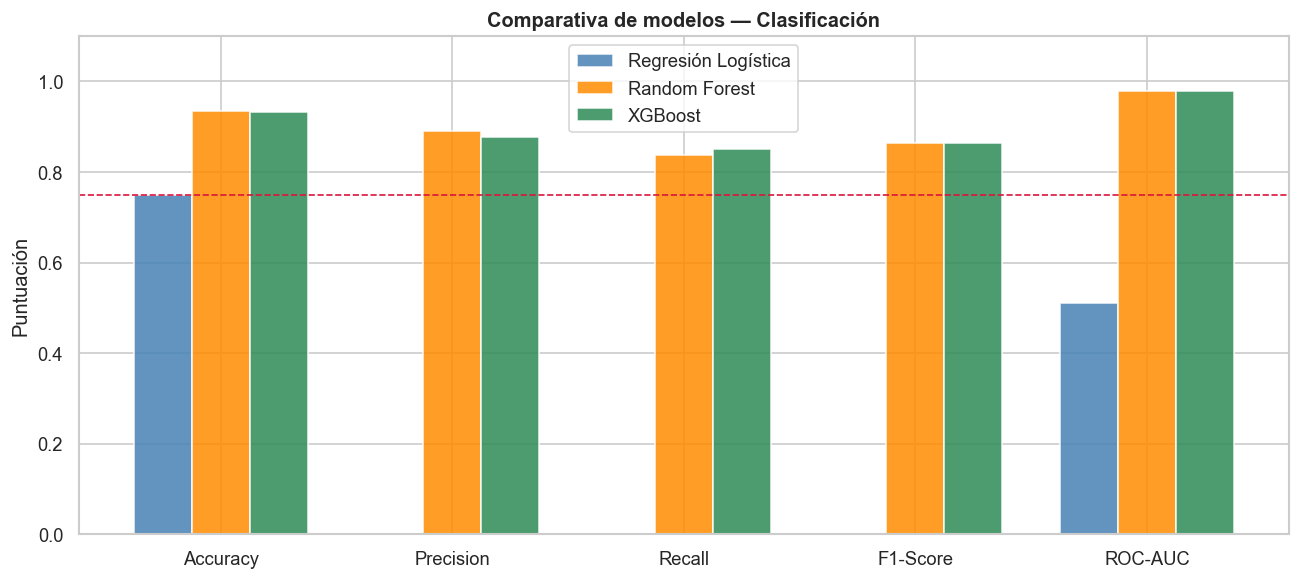

In [10]:
# Configuración de gráfico.
fig, ax = plt.subplots(figsize=(11, 5))

# Selección de métricas.
metricas = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(metricas))
width = 0.25
colores = ['steelblue','darkorange','seagreen']

# Gráficos.
for i, (modelo, row) in enumerate(resultados_class.iterrows()):
    ax.bar(x + i * width, row[metricas], width,
           label=modelo, color=colores[i], alpha=0.85, edgecolor='white')

# Etiquetas y formato.
ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de modelos — Clasificación', fontweight='bold')
ax.legend()
ax.axhline(0.75, color='crimson', linestyle='--', linewidth=1,
           label='Baseline (accuracy trivial)')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_comparativa_clasificacion.png', dpi=120, bbox_inches='tight')
plt.show()

El modelo de regresión logística tiene unos resultados bastante decepcionantes comparado con los otros dos. XGBoost y RandomForest tiene unos números bastantes similares y decentes.

Continuamos con las curvas ROC.

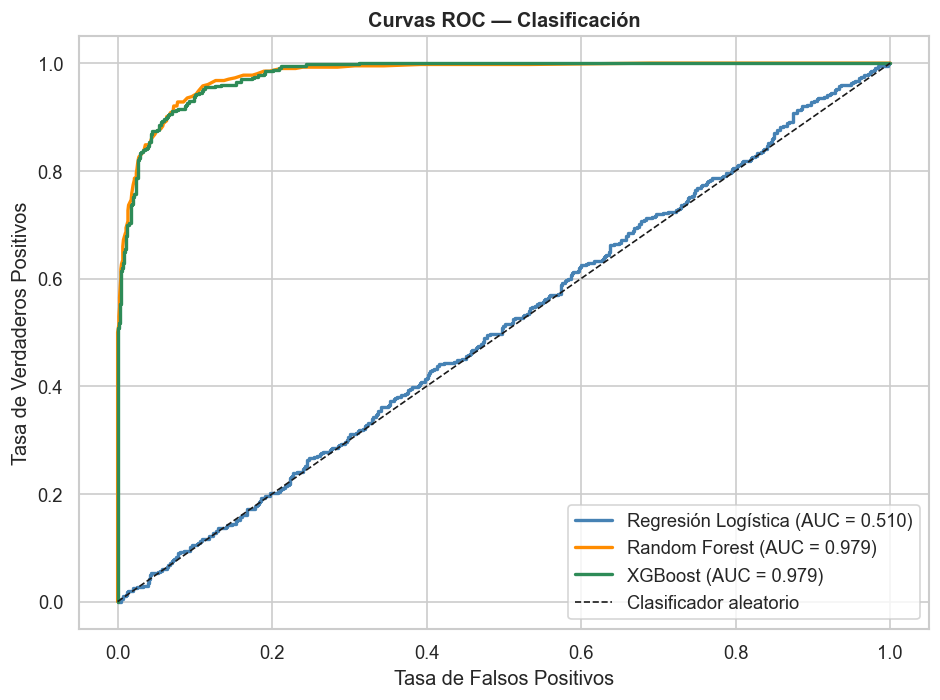

In [11]:
# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(8,6))

# Selección de modelos.
modelos_roc = [
    ('Regresión Logística', lr_class, X_test_scaled, 'steelblue'),
    ('Random Forest', rf_class, X_test_class, 'darkorange'),
    ('XGBoost', xgb_class, X_test_class, 'seagreen')
]

# Dibujo de curvas ROC.
for nombre, modelo, X_test, color in modelos_roc:
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_class, y_proba)
    auc = roc_auc_score(y_test_class, y_proba)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', color=color, linewidth=2)

# Etiquetas.
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Clasificación', fontweight='bold')
ax.legend(loc='lower right')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_curvas_roc.png', dpi=120, bbox_inches='tight')
plt.show()

El modelo de regresión logística es prácticamente un clasificador aleatorio, no interesa su uso. 

Por otro lado, los modelos de Random Forest y XGBoost muestran unos resultados excelentes y muy similares. Tienen prácticamente el mismo AUC-ROC. 
RandomForest tiene un poco más de precisión, pero XGBoost tiene mayor recall (ambos diferenciados por muy poco). El recall será la métrica prioritaria, debido a que se prefiere detectar todos los casos de riesgo aunque haya algún falso positivo.

El modelo seleccionado será **XGBoost**.

El modelo seleccionado para clasificación es XGBoost.


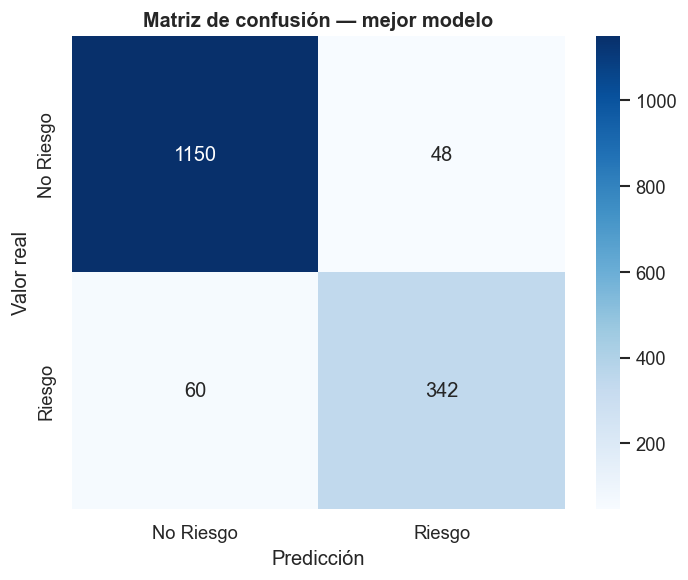

              precision    recall  f1-score   support

  Sin riesgo       0.95      0.96      0.96      1198
   En riesgo       0.88      0.85      0.86       402

    accuracy                           0.93      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.93      0.93      0.93      1600



In [12]:
# Selección de mejor modelo.
mejor_modelo_class = xgb_class
X_test_mejor_class = X_test_class
y_pred_mejor_class = mejor_modelo_class.predict(X_test_mejor_class)
print(f'El modelo seleccionado para clasificación es XGBoost.')

# Mostramos matriz de confusión.
cm = confusion_matrix(y_test_class, y_pred_mejor_class)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['No Riesgo', 'Riesgo'], yticklabels=['No Riesgo', 'Riesgo'])

# Mostramos etiquetas.
ax.set_title('Matriz de confusión — mejor modelo', fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# Mostramos el reporte de clasificación.
print(classification_report(y_test_class, y_pred_mejor_class,target_names=['Sin riesgo', 'En riesgo']))

Podemos comprobar que la tasa de verdaderos (tanto como positivos como negativos) es bastante alta; 1492 casos de 1600 posibles, un 93% de precisión general.

A partir de aquí hay que poner el foco en los falsos negativos, debido a que es el error que más coste puede suponer, un alumno que no se encuentre en riesgo pero en realidad si lo esté.

De este tipo, hay 60 casos, aproximadamente un 4% de los casos. Es un buen número para un primer modelo inicial. 

Como hemos comentado en los anteriores notebooks, el modelo tiene un pequeño desbalance en la cantidad de estudiantes en riesgo y sin riesgo, se puede observar que las predicciones de las clases minoritarias tienen unos resultados algo peores.


## 03 - Regresión

El objetivo de este modelo es predecir la nota exacta de un alumno. Se utilizarán los mismos 3 modelos pero con métricas distintas.

Primero, se escalarán los datos para la regresión lineal.

In [13]:
# Standard scaler.
scaler_reg = StandardScaler()

X_train_scaled_reg = scaler_reg.fit_transform(X_train_reg) # Solo se ajusta con el train para evitar data leakage.
X_test_scaled_reg = scaler_reg.transform(X_test_reg) # Se transforma con el scaler ajustado con el train.

print(f'Escalado aplicado.')

Escalado aplicado.


Continuamos configurando y entrenando los 3 modelos.

In [14]:
# Modelo 1 - Regresión lineal.
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled_reg, y_train_reg)
print(f'Entrenamiento de regresión lineal completado.')

# Modelo 2 - Random forest.
rf_reg = RandomForestRegressor(random_state=42, n_estimators=100)
rf_reg.fit(X_train_reg, y_train_reg)
print(f'Entrenamiento de random forest completado.')

# Modelo 3 - XGBoost.
xgb_reg = XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
xgb_reg.fit(X_train_scaled_reg, y_train_reg)
print(f'Entrenamiento de XGBoost completado.')

print(f'...')
print(f'Los 3 modelos han sido entrenados correctamente.')

Entrenamiento de regresión lineal completado.
Entrenamiento de random forest completado.
Entrenamiento de XGBoost completado.
...
Los 3 modelos han sido entrenados correctamente.


Una vez se han entrenado los modelos, repetimos las evaluaciones comparativas.

In [15]:
def evaluar_regresor(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    return {
        'Modelo' : nombre,
        'RMSE'   : rmse,
        'MAE'    : mae,
        'R²'     : r2
    }

resultados_reg = pd.DataFrame([
    evaluar_regresor('Regresión Lineal', lr_reg,  X_test_scaled_reg, y_test_reg),
    evaluar_regresor('Random Forest',     rf_reg,  X_test_reg,        y_test_reg),
    evaluar_regresor('XGBoost',           xgb_reg, X_test_reg,        y_test_reg),
])

resultados_reg.set_index('Modelo', inplace=True)
resultados_reg.round(4)

,RMSE,MAE,R²
Modelo,,,
Regresión Lineal,6.9348,5.5120,0.9021
Random Forest,6.1193,4.7246,0.9238
XGBoost,37.5955,31.3159,-1.8772


Estas métricas se interpretan de la siguiente forma:

- El RMSE es el error medio que tiene el modelo en las mismas unidades que grades. Aquí, XGBoost es claramente el que peor predice.

- El MAE es similar solo que es menos sensible a errores grandes. Es más interpretable, pero similar a RMSE, es decir, XGboost no mejora considerablemente.

- R"2 es la proporción de varianza explicada por el modelo. Cuanto más alta, significa que el modelo explica el % de la variabilidad de las notas.

Como resumen, el modelo XGBoost no funciona como regresor lineal. RandomForest tiene un MAE inferior y tiene un R2 más alto, por lo tanto será el modelo seleccionado.

Visualizaremos estas métricas en distintos gráficos.

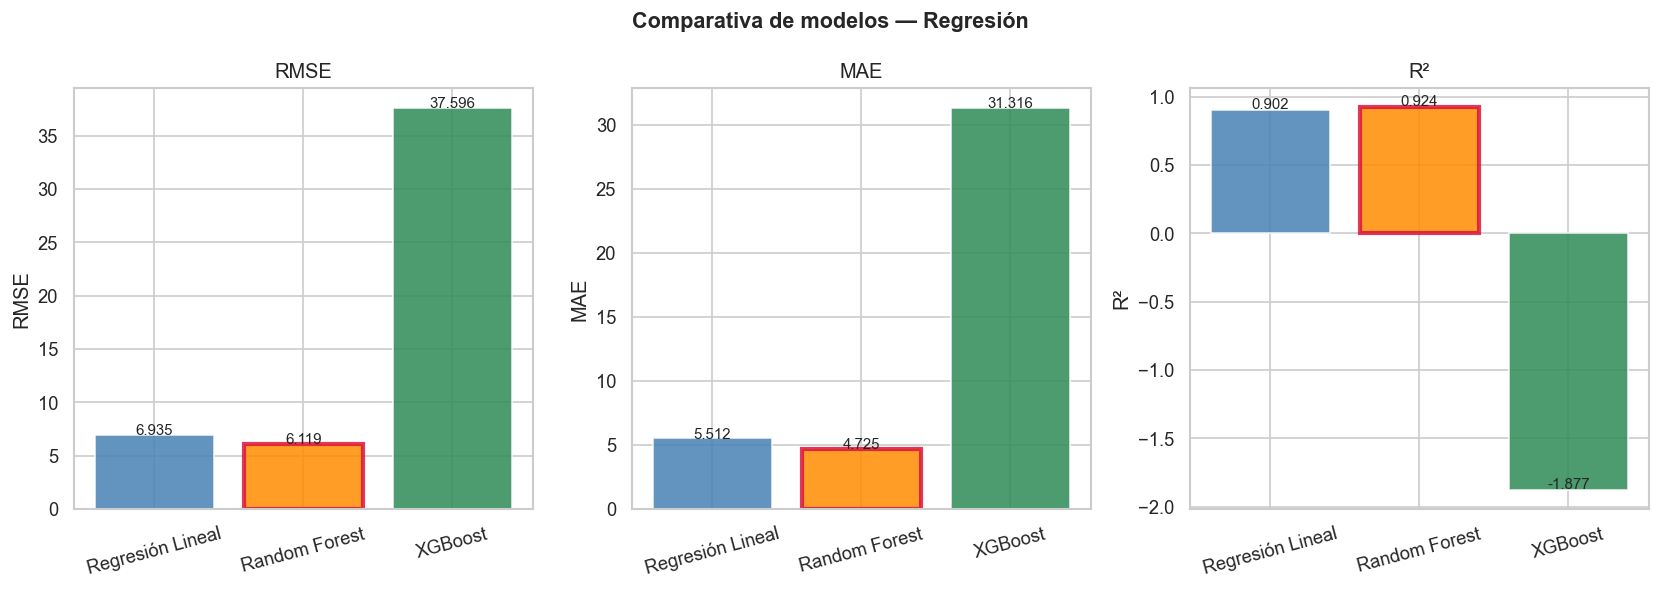

In [16]:
# Configuración del gráfico.
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparativa de modelos — Regresión', fontsize=13, fontweight='bold')
colores = ['steelblue', 'darkorange', 'seagreen']
modelos = resultados_reg.index.tolist()

# Gráficos.
for ax, metrica, mejor_es in zip(axes, ['RMSE', 'MAE', 'R²'], ['min', 'min', 'max']):
    valores = resultados_reg[metrica].values
    bars = ax.bar(modelos, valores, color=colores, alpha=0.85, edgecolor='white')
    
    # Resaltar el mejor
    idx_mejor = np.argmin(valores) if mejor_es == 'min' else np.argmax(valores)
    bars[idx_mejor].set_edgecolor('crimson')
    bars[idx_mejor].set_linewidth(2.5)
    
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)
    
    ax.set_title(metrica)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=15)

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_comparativa_regresion.png', dpi=120, bbox_inches='tight')
plt.show()

XGboost es el modelo más avanzado pero obtiene resultados muy pobres como regresor para este dataset. Este modelo requiere de un ajuste de hiperparámetros, como learning_rate, maxdepth o subsample entre otros, para funcionar bien en regresión. Se podrían utilizar librerías de optimización de hiperparámetros como GridSearchCV.

Los modelos de Regresión Lineal y Random Forest ofrecen resultados más sólidos. RandomForest obtiene un 0,92 de R2, es decir, el modelo explica el 92% de la variabilidad de los datos. 

Por estos motivos, el modelo seleccionado es **Random Forest**.

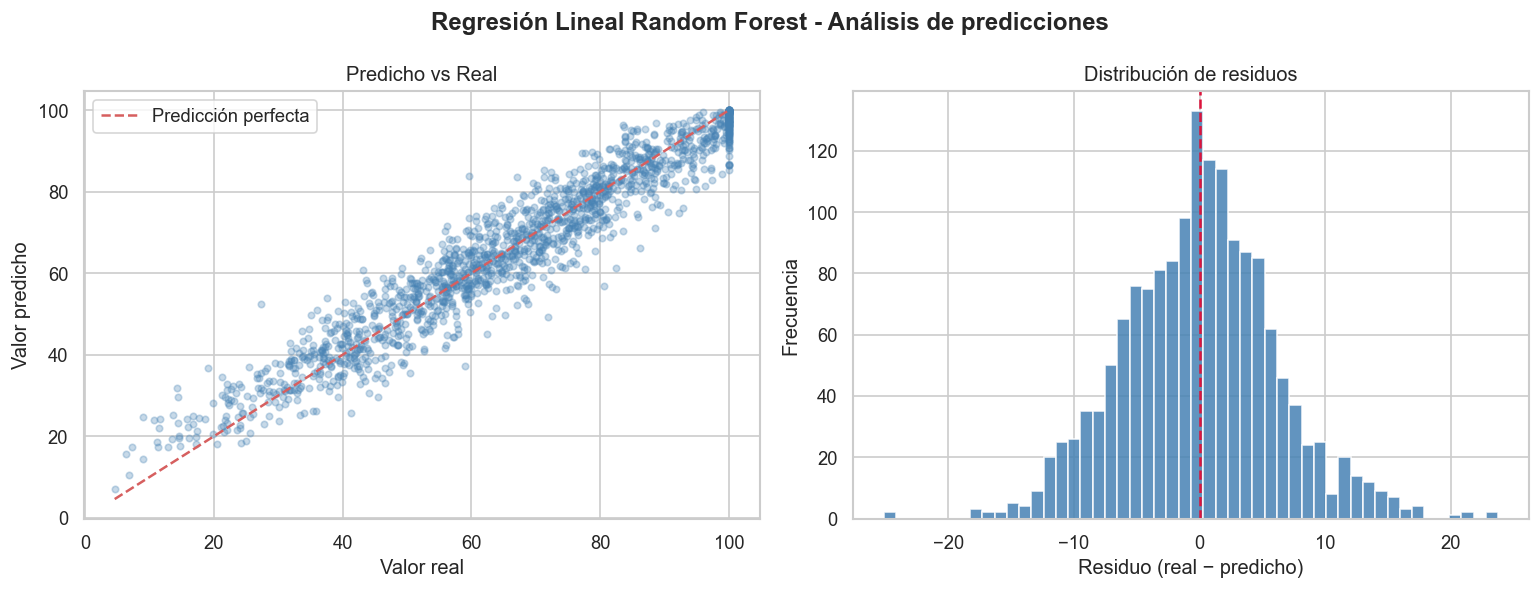

RMSE : 6.119
MAE  : 4.725
R²   : 0.9238


In [17]:
# Selección de modelo.
mejor_modelo_reg = rf_reg
X_test_mejor_reg = X_test_reg

# Realizar predicciones.
y_pred_reg = mejor_modelo_reg.predict(X_test_mejor_reg)

# Demostración en gráfico.
fig, axes = plt.subplots(1,2, figsize=(13,5))
fig.suptitle('Regresión Lineal Random Forest - Análisis de predicciones', fontweight='bold')

# Predicciones vs reales.
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.3, color='steelblue', s=15)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Predicho vs Real')
axes[0].legend()

# Distribución de residuos
residuos = y_test_reg - y_pred_reg
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_predicciones_regresion.png', dpi=120, bbox_inches='tight')
plt.show()

# Métricas de evaluación.
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.3f}')
print(f'MAE  : {mean_absolute_error(y_test_reg, y_pred_reg):.3f}')
print(f'R²   : {r2_score(y_test_reg, y_pred_reg):.4f}')

## 04 - Clustering

Este modelo tiene como objetivo descubrir si existen perfiles naturales de estudiante en los datos sin usar etiquetas. 

El primer paso será preparar las variables para el clustering.

In [19]:
# Selección de variables.
feat_cluster = ['gaming_hours', 'study_hours', 'sleep_hours',
    'attendance', 'addiction_score', 'reaction_time_ms',
    'stress_level_enc', 'social_activity']

X_cluster = df[feat_cluster].copy()

# Aplicamos escalado. KMeans utiliza distancias euclídeas, por tanto es obligatorio. 
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f'Features para clustering: {feat_cluster}')
print(f'Shape: {X_cluster_scaled.shape}')

Features para clustering: ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'addiction_score', 'reaction_time_ms', 'stress_level_enc', 'social_activity']
Shape: (8000, 8)


Buscaremos el K óptimo mediante el método del codo.

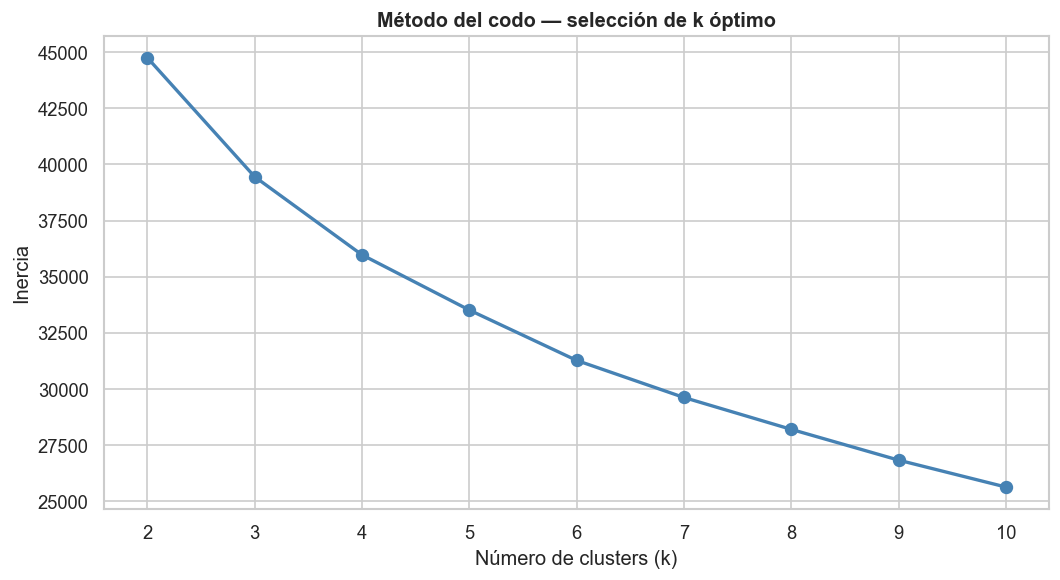

In [20]:
inercias = []
rango_k = range(2,11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

# Graficamos.
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2, markersize=7)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Método del codo — selección de k óptimo', fontweight='bold')
ax.set_xticks(list(rango_k))

# Mostramos gráfico.
plt.tight_layout()
plt.savefig('./img/fig_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

No hay un cambio muy pronunciado en la pendiente. Quizás los pasos más pronunciados son entre k=2 y k=3, y entre k=4 y k=5.

En el siguiente gráfico nos dará la solución correctamente.

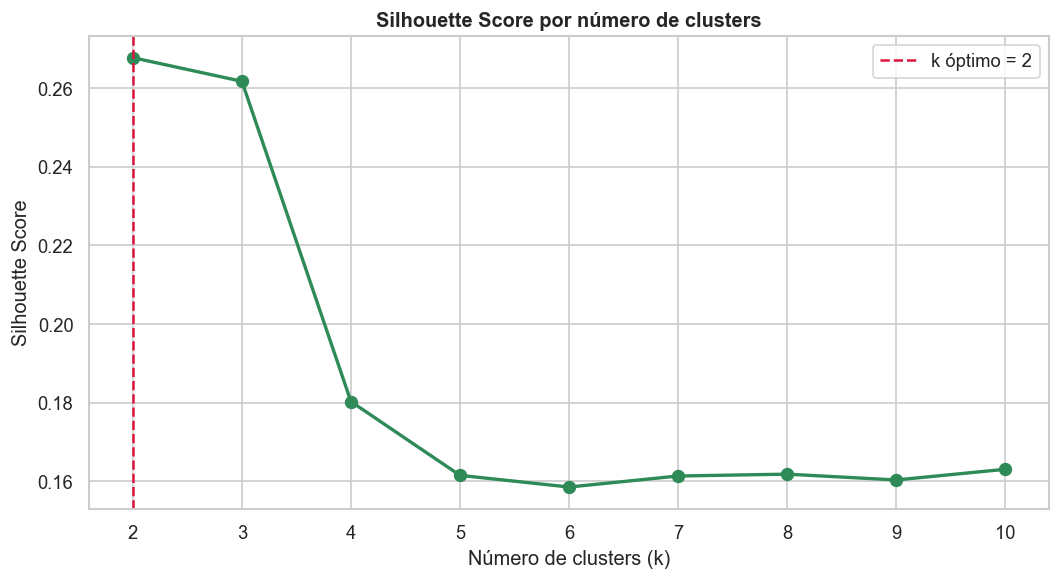

k con mayor Silhouette Score: 2
  k=2: 0.2677
  k=3: 0.2617
  k=4: 0.1802
  k=5: 0.1615
  k=6: 0.1585
  k=7: 0.1613
  k=8: 0.1618
  k=9: 0.1603
  k=10: 0.1630


In [21]:
silhouette_scores = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score  = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

# Gráfico.
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(rango_k, silhouette_scores, marker='o', color='seagreen', linewidth=2, markersize=7)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por número de clusters', fontweight='bold')
ax.set_xticks(list(rango_k))

# Marcar el máximo
k_optimo = rango_k[np.argmax(silhouette_scores)]
ax.axvline(k_optimo, color='crimson', linestyle='--', linewidth=1.5,
           label=f'k óptimo = {k_optimo}')
ax.legend()

# Mostrar el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'k con mayor Silhouette Score: {k_optimo}')
for k, s in zip(rango_k, silhouette_scores):
    print(f'  k={k}: {s:.4f}')

Finalmente, el valor óptimo es k = 2, por muy poca diferencia.

Continuamos entrenando el modelo final.

In [22]:
# Ajuste de K.
k_optimo = 2

# Entrenamiento.
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_cluster_scaled)

# Resultados finales.
print(f'K-Means entrenado con k={k_optimo}')
print()
print('Distribución de estudiantes por cluster:')
print(df['cluster'].value_counts().sort_index())

K-Means entrenado con k=2

Distribución de estudiantes por cluster:
cluster
0    3583
1    4417
Name: count, dtype: int64


Una distribución binaria. 

Realizaremos una visualización 2D para una visualización más sencilla.

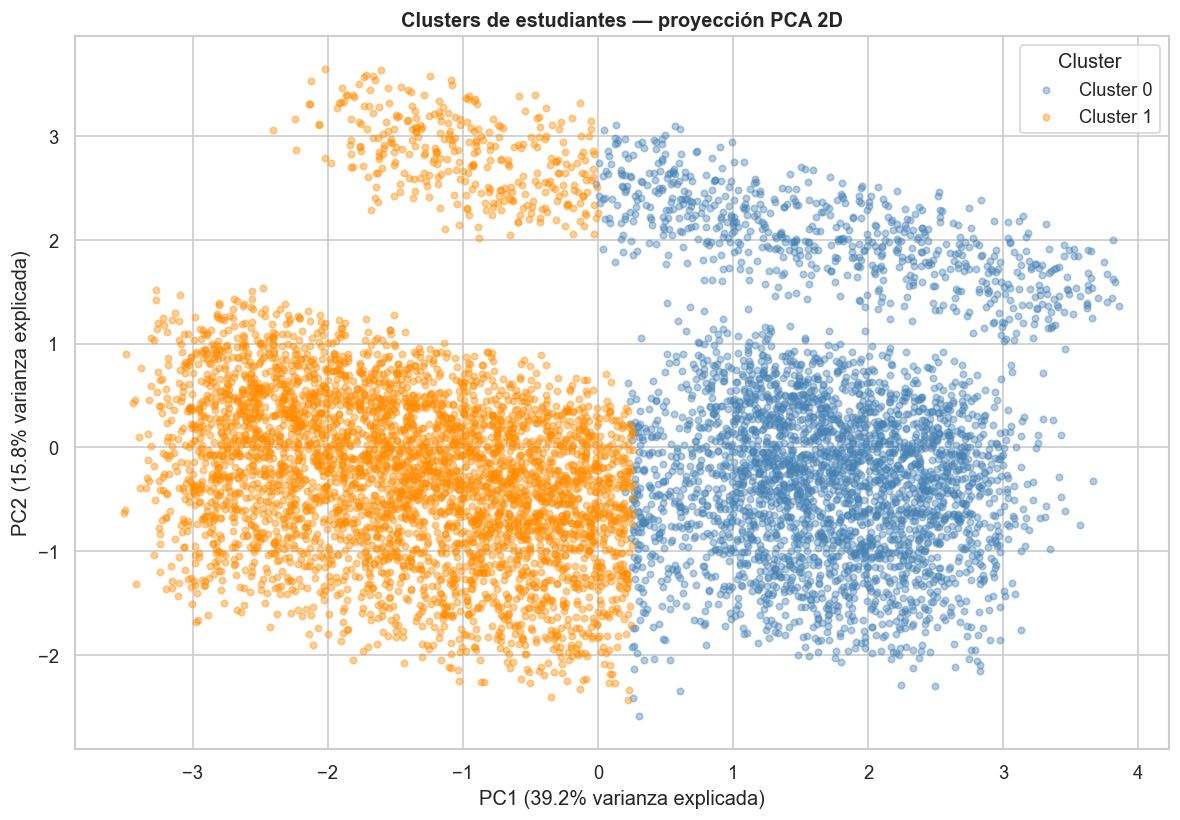

Varianza total explicada por PC1+PC2: 55.0%


In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
varianza = pca.explained_variance_ratio_ 

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(10,7))
colores_cluster = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']

# Gráficos.
for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {cluster_id}',
               color=colores_cluster[cluster_id],
               alpha=0.4, s=15)

ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza explicada)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza explicada)')
ax.set_title('Clusters de estudiantes — proyección PCA 2D', fontweight='bold')
ax.legend(title='Cluster')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Varianza total explicada por PC1+PC2: {sum(varianza)*100:.1f}%')

Confirmamos que K=2 es la elección correcta, debido a que se puede contemplar una separación bastante clara en torno al 0.

K-Means trabaja en un espacio de 8 dimensiones que no es posible proyectar, por tanto, PCA reduce esas 8 dimensiones a 2, preservando la mayor varianza posible y permitiendo ver los clusters en un plano. El porcentaje de varianza explicada indica cuánta información se conserva en la proyección.

Mostraremos los registros medios que tienen cada cluster, y posteriormente se presentarán en un heatmap.

In [25]:
perfil_clusters = df.groupby('cluster')[feat_cluster + ['grades', 'risk_flag']].mean().round(2)
perfil_clusters

,gaming_hours,study_hours,sleep_hours,attendance,addiction_score,reaction_time_ms,stress_level_enc,social_activity,grades,risk_flag
cluster,,,,,,,,,,
0,6.21,5.67,6.39,80.09,14.20,245.19,0.86,2.54,55.86,0.43
1,2.37,5.29,6.58,79.73,6.45,292.13,1.85,2.48,74.37,0.10


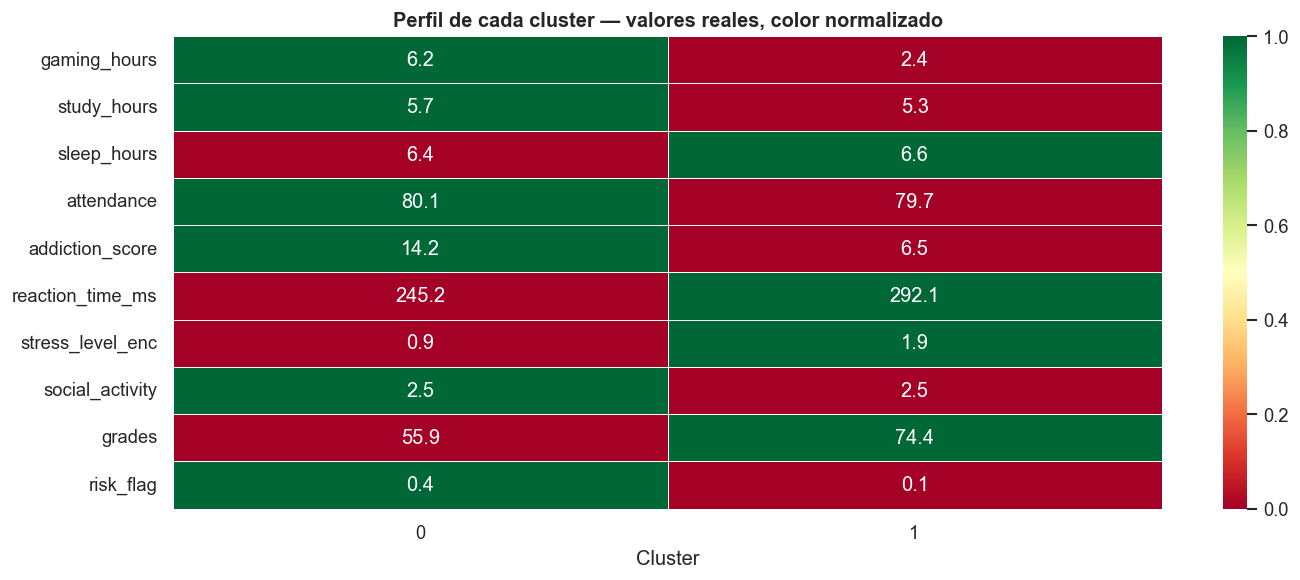

In [27]:
# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(12, 5))

perfil_norm = (perfil_clusters - perfil_clusters.min()) / \
              (perfil_clusters.max() - perfil_clusters.min())

# Gráfico.
sns.heatmap(perfil_norm.T, annot=perfil_clusters.T, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, ax=ax)

ax.set_title('Perfil de cada cluster — valores reales, color normalizado',
             fontweight='bold')
ax.set_xlabel('Cluster')

# Mostrar gráficos.
plt.tight_layout()
plt.savefig('./img/fig_cluster_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación de clusters

| Característica | Cluster 0 | Cluster 1 |
|---|---|---|
| gaming_hours | **Mayor** | Menor |
| addiction_score | **Mayor** | Menor |
| study_hours | **Mayor** | Menor |
| attendance | **Mayor** | Menor |
| grades | 55.9 | **74.4** |
| risk_flag | 0.40 | **0.10** |

**Cluster 0**

Refleja al estudiante comprometido pero en riesgo.Tiene una mayor implicación académica (más horas de estudio y asistencia) pero
también mayor exposición al gaming. 

El esfuerzo no compensa el impacto negativo del gaming intensivo. 4 de cada 10 estudiantes de este grupo
están en riesgo académico.

**Cluster 1**

Muestra un estudiante más equilibrado. Menos horas de gaming y menor índice de adicción. 

Pese a estudiar menos horas, obtiene notas significativamente mejores (74.4 vs 55.9).
Solo 1 de cada 10 está en riesgo académico.



Un hallazgo interesante es que estudiar más horas no neutraliza el efecto negativo del gaming excesivo. 
La calidad del tiempo de estudio importa más que la cantidad cuando hay alta exposición al gaming.

In [ ]:
# Exportamos el dataset.
cluster_nombres = {
    0: 'Comprometido en riesgo',
    1: 'Equilibrado'
}

df['cluster_nombre'] = df['cluster'].map(cluster_nombres)

print(df['cluster_nombre'].value_counts())

# Exportar con los nombres
df.to_csv('./data/GAP_clean_v2.csv', index=False)
print('Dataset exportado con cluster_nombre.')

cluster_nombre
Equilibrado               4417
Comprometido en riesgo    3583
Name: count, dtype: int64
Dataset exportado con cluster_nombre.


## 05 - Feature Importance 

Analizaremos qué variables tienen más peso en las predicciones de los dos mejores modelos. De esta forma, encontraremos la respuesta a la pregunta:

¿Qué factores determinan realmente el rendimiento académico?

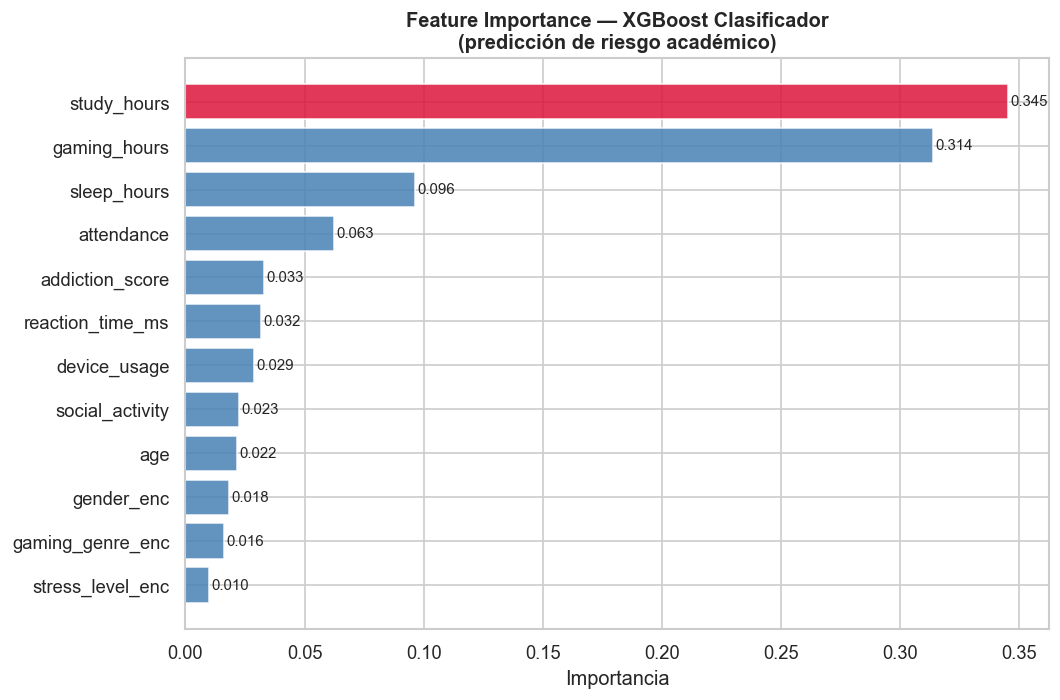

In [29]:
# Clasificador (XGBoost)
importancias_clf = pd.Series(xgb_class.feature_importances_,index=features).sort_values(ascending=True)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(9, 6))
colores = ['crimson' if v == importancias_clf.max() else 'steelblue' for v in importancias_clf.values]

# Crear gráfico.
ax.barh(importancias_clf.index, importancias_clf.values,color=colores, alpha=0.85, edgecolor='white')
ax.set_title('Feature Importance — XGBoost Clasificador\n(predicción de riesgo académico)', fontweight='bold')
ax.set_xlabel('Importancia')
for i, v in enumerate(importancias_clf.values):ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)


# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_importance_clasificacion.png', dpi=120, bbox_inches='tight')
plt.show()

El resultado es coherente. El factor más importante para saber si un alumno se encuentra en riesgo académico es la tiempo de estudio.

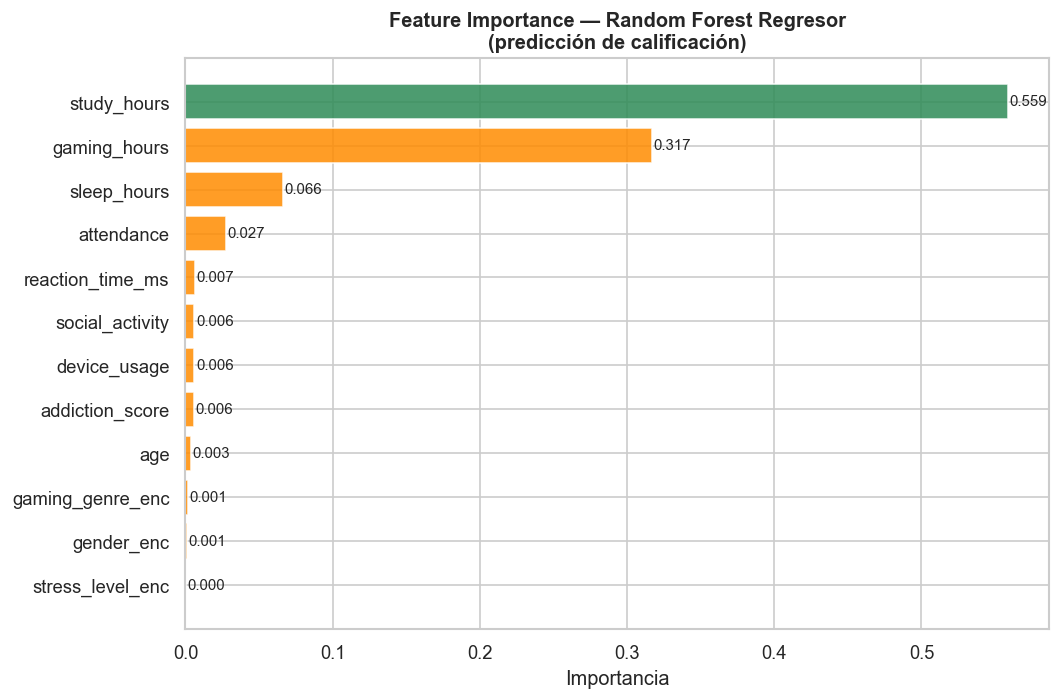

In [30]:
# Regresor (Random Forest)
importancias_reg = pd.Series(rf_reg.feature_importances_,index=features).sort_values(ascending=True)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(9, 6))
colores = ['seagreen' if v == importancias_reg.max() else 'darkorange' for v in importancias_reg.values]

# Gráfico.
ax.barh(importancias_reg.index, importancias_reg.values, color=colores, alpha=0.85, edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regresor\n(predicción de calificación)', fontweight='bold')
ax.set_xlabel('Importancia')

for i, v in enumerate(importancias_reg.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_importance_regresion.png', dpi=120, bbox_inches='tight')
plt.show()

Para el regresor también son las horas de estudio el factor más importante para realizar predicciones.

Finalmente, vamos a realizar la comparativa de importancias entre ambos modelos.

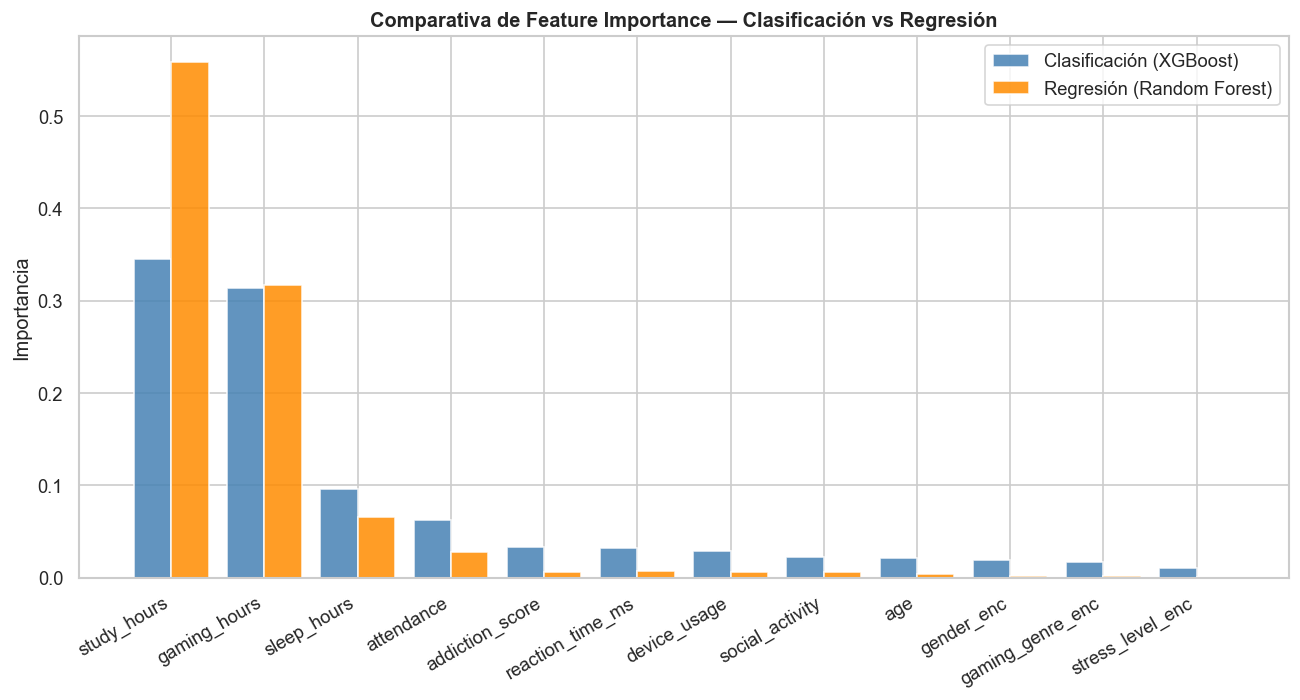

Ranking comparativo:
                  Clasificación (XGBoost)  Regresión (Random Forest)
study_hours                        0.3453                     0.5586
gaming_hours                       0.3140                     0.3169
sleep_hours                        0.0962                     0.0660
attendance                         0.0626                     0.0274
addiction_score                    0.0328                     0.0059
reaction_time_ms                   0.0316                     0.0066
device_usage                       0.0286                     0.0061
social_activity                    0.0227                     0.0061
age                                0.0216                     0.0035
gender_enc                         0.0185                     0.0012
gaming_genre_enc                   0.0163                     0.0015
stress_level_enc                   0.0099                     0.0003


In [ ]:
# Creación de dataframe para comparar.
comparativa = pd.DataFrame({
    'Clasificación (XGBoost)'  : xgb_class.feature_importances_,
    'Regresión (Random Forest)' : rf_reg.feature_importances_
}, index=features).sort_values('Clasificación (XGBoost)', ascending=False)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(features))
width = 0.4

# Gráfico.
ax.bar(x - width/2, comparativa['Clasificación (XGBoost)'], width,
       label='Clasificación (XGBoost)', color='steelblue', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, comparativa['Regresión (Random Forest)'], width,
       label='Regresión (Random Forest)', color='darkorange', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comparativa.index, rotation=30, ha='right')
ax.set_title('Comparativa de Feature Importance — Clasificación vs Regresión',
             fontweight='bold')
ax.set_ylabel('Importancia')
ax.legend()

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_importance_comparativa.png', dpi=120, bbox_inches='tight')
plt.show()

print('Ranking comparativo:')
print(comparativa.round(4))

Las variables más importantes en ambos modelos son:

1º **Horas de estudio** ('study_hours')

2º **Horas de gaming** ('gaming_hours')

3º **Horas de sueño** ('sleep_hours')

Los dos modelos coinciden exactamente en el top 3 de variables más importantes, a pesar de tener arquitecturas y finalidades distintas. Esto muestra que los hallazgos obtenidos son sólidos.

Las horas de estudio son el predictor más importante del rendimiento académico. 
Las horas de gaming son el segundo factor más determinante, con impacto negativo sobre las calificaciones.
Las horas de sueño cierran el top 3. El descanso es el tercer pilar del rendimiento académico, por delante de la asistencia a clase o el nivel de estrés.


## Conclusión

### Resumen del pipeline

Este notebook ha abordado tres tareas de Machine Learning sobre
8.000 estudiantes universitarios:

| Tarea | Modelo seleccionado | Métrica principal |
|---|---|---|
| Clasificación (riesgo académico) | XGBoost | ROC-AUC = 0.979 |
| Regresión (predicción de nota) | Random Forest | R² = 0.92 |
| Clustering (segmentación) | K-Means (k=2) | Silhouette Score |

---

### Hallazgos del modelo

**Clasificación:**

- XGBoost predice con un ROC-AUC de 0.979 el riesgo académico de un estudiante, con un recall superior a RandomForest.

- La regresión logística no supera el 75%, confirmando que la frontera de decisión entre clases no es linealmente separable.

**Regresión:**

- RandomForest explica el 92% de la variabilidad de las notas, con un error medio de 4.72 puntos (MAE).

- XGBoost no funciona como regresor con los hiperparámetros por defecto, demostrando que un modelo más complejo no siempre es mejor.

**Clustering:**

- K-Means identifica dos perfiles naturales de estudiante:

    - **Cluster 0 - Comprometido en riesgo:** Mayor exposición al gaming y mayor esfuerzo académico, pero peor rendimiento. 4 de cada 10 se encuentran en riesgo académico.

    - **Cluster 1 - Equilibrado:** Menor exposición al gaming y mejores notas pese a estudiar menos horas. Solo 1 de cada 10 está en riesgo académico.

**Feature Importance:**

- Los tres predictores más importantes coinciden en clasificación y regresión: `study_hours`, `gaming_hours` y `sleep_hours`.

- La robustez del ranking entre dos modelos distintos refuerza la validez de los hallazgos.

El mensaje obtenido de este proceso es que el rendimiento académico depende principalmente de 3 factores: cuánto estudia el estudiante, cuánto juega y cuánto duerme. Además, el gaming excesivo daña el rendimiento incluso cuando el estudiante intenta compensarlo con más horas de estudio.

---

El próximo paso será el paso el desarrollo del un dashboard con PowerBI. 
